In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il
import pickle
from scipy.optimize import curve_fit
import scipy

In [3]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM11-11.1.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk110 = pickle.load(f)
print("shotnoise", Pk110.attrs["shotnoise"])

shotnoise 286.3949289238728


In [4]:
from nbodykit.lab import cosmology as n_cosmology
#c      = n_cosmology.Planck15
#n_cosmology.P_k_max=100
c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [5]:
def kernel_lin(ks, R=1, nbins=100):
    dx = 2*R
    results = []
    r = np.linspace(0, dx, nbins)
    xi = cf_lin(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*dx)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [6]:
def W_R(k, R=1):
    R = 2*R
    return 3 * (np.sin(k*R) - k*R*np.cos(k*R))/(k*R)**3

In [7]:
def V_excl(R=1):
    R = 2*R
    return (4*np.pi*R**3)/3

In [8]:
def result_k(k, R):
    result2 = -V_excl(R)*W_R(k,R)
    return result2

In [9]:
def fit_pow(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1, kernel_type="lin"):
    #bias_k = scale_dependent_bias(logk, a, b, c, d, logk0)
    bias_k = 1

    #mask = logk < logk0
    #result[mask] = a
    if kernel_type == "lin":
        kernel = kernel_lin(10**logk, R=R)
    elif kernel_type == "new":
        kernel = kernel_new(10**logk, R=R)
    elif kernel_type == "nl":
        kernel = kernel_NL(10**logk, R=R)
    dx = 2*R
    
    result1 = bias_k*Plin(10**logk) - bias_k*kernel - ((4*np.pi*dx**3)/3)*W_R(10**logk, R)
    
    return result1

In [10]:
logks = np.log10(Pk110["k"])

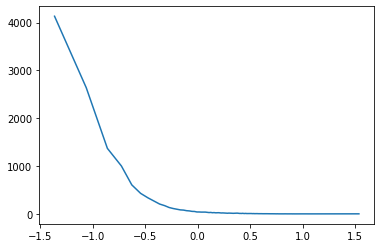

In [11]:
plt.plot(np.log10(Pk110["k"]),(Pk110["power"].real-Pk110.attrs["shotnoise"]))


(-50.0, 50.0)

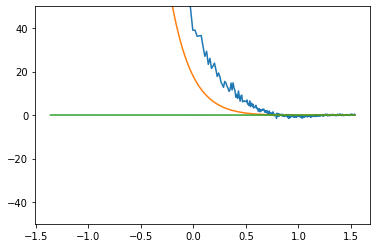

In [12]:
R = 0.1
pk = fit_pow(logks, R=R)
plt.plot(np.log10(Pk110["k"]),(Pk110["power"].real-Pk110.attrs["shotnoise"]))
plt.plot(logks, pk)
plt.plot(logks, -result_k(10**logks, R=R))
plt.ylim(-50,50)

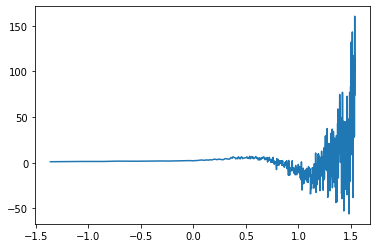

In [51]:
plt.plot(np.log10(Pk110["k"]),(Pk110["power"].real-Pk110.attrs["shotnoise"])/Plin(Pk110["k"]))


(-50.0, 50.0)

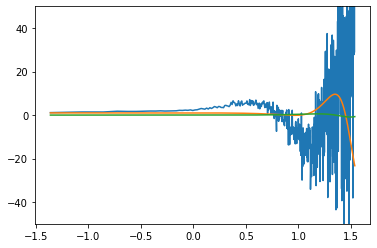

In [53]:
R = 0.1
pk = fit_pow(logks, R=R)
plt.plot(np.log10(Pk110["k"]),(Pk110["power"].real-Pk110.attrs["shotnoise"])/Plin(Pk110["k"]))
plt.plot(logks, pk/Plin(Pk110["k"]))
plt.plot(logks, -result_k(10**logks, R=R)/Plin(Pk110["k"]))
plt.ylim(-50,50)

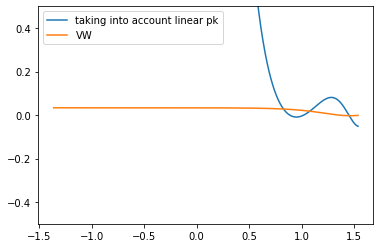

In [56]:
R = 0.1
pk = fit_pow(logks, R=R)
plt.plot(logks, pk, label="taking into account linear pk")
plt.plot(logks, -result_k(10**logks, R=R), label="VW")
plt.ylim(-0.5,0.5)
plt.legend()

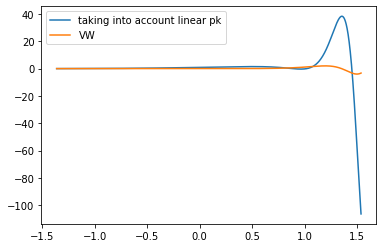

In [59]:
R = 0.1
pk = fit_pow(logks, R=R)
ks = 10**logks
kcoef = ks**3/(2*np.pi**2)
plt.plot(logks, kcoef*pk, label="taking into account linear pk")
plt.plot(logks, -kcoef*result_k(10**logks, R=R), label="VW")
#plt.ylim(-0.5,0.5)
plt.legend()